# Verifying `tab:relationship-classes`

This notebook checks the eleven rows of `tab:relationship-classes` (section 2.3 of
`relative_covariance.tex`). **Keep the compiled PDF open beside it**: each section names what
it is checking and restates that one formula, and never re-derives anything.

## The table has two legs, not three

The task was framed as a three-way comparison — closed-form formula, pathMgr symbolic oracle,
and simulation — with each disagreement localizing a different failure. That framing was
right, but the result collapses it, and the honest presentation says so.

**The formula leg and the oracle leg are not two pieces of evidence. They are one statement,
proved.** `three_way.py` establishes that they are *identically equal as expressions* in
`(V_A, rho_g, rho_y)` for all eleven rows at both levels — not agreeing at sampled parameter
values, but equal as functions. An identity is not evidence in the probabilistic sense; it is
a proof. So presenting three agreeing columns would be presenting the same statement twice
and counting it as corroboration.

What makes the identity meaningful is *which* implementations it spans:

| implementation | what it is |
|---|---|
| `simulation/theory.py` | my hand transcription of the writeup |
| `popstatgensim.pedigree.predicted_cov` | their independent hand transcription |
| `pathmgr.genetics.RelativeOracle` | **derives** the answer from a path model |

Two transcriptions agreeing rules out arithmetic slips but *not* a shared misreading of the
prose — and a shared misreading is the likelier error, since both were written by reading the
same `.tex`. Only the derived leg rules that out. So the claim is not "three legs agree" but
**"a derivation and two independent readings of the writeup agree"**, which is stronger and
different.

That leaves **simulation as the one genuinely independent leg**, exactly as in the
equilibrium tier.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd()))

import classes_sim
import generate_populations as gen
import theory
import three_way

plt.rcParams.update({"figure.figsize": (8, 4.5), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})

for name in ("classes-monogamous", "classes-multimate"):
    print(f"{name:<22} {len(gen.available(name))} replicate populations on disk")

classes-monogamous     8 replicate populations on disk
classes-multimate      8 replicate populations on disk


---
## 1. The identity: formula $\equiv$ oracle, for every row at both levels

Run first, because it is a precondition rather than a result. Two things it establishes:

1. The writeup's algebra is self-consistent for all eleven rows — so any disagreement found
   later localizes to the simulator or a violated assumption, not to the derivation.
2. **Convention consistency across legs.** `eq:chain-weight-cases` silently excludes the
   `N_mu = 1, N_o = 1` cell, and a convention applied on one leg but not the other produces a
   disagreement with *exactly the signature* this table is built to read as "algebra error in
   the writeup". A mismatched convention is indistinguishable from the finding the table
   exists to detect, so consistency has to be checked before the table means anything.

In [2]:
three_way.main()

=== 1. is the N_mu=1, N_o=1 cell handled consistently across legs? ===
    their predicted_cov REFUSES the (1,1) route: ValueError: Signature contains an inadmissible (N_mu=1, N_o=1) mating chain. One mating edge feeding one descending lineal chain IS that descent, so the path double-counts the meiosis and the entering proband wrongly takes the terminal-mating correction 1/h^2 -- inflating the answer by (1+rho_g)/(h^2(1+rho_y)). The writeup's own make_figures.py excludes this cell ("N_mu = N_U = 1 is a meiosis, absorbed into a lineal chain"). Use the lineal signature instead: PathSignature(n, 0, ()).
    their chain_weight(N_mu=1, N_o=1) = 0.5*(1.0*rho_g + 1.0)
    my   chain_weight(N_mu=1, N_o=1) = 0.5*(1.0*rho_g + 1.0)
    Both transcriptions COMPUTE the cell -- eq:chain-weight's binomial form is defined there. The exclusion is a claim about which PATHS are admissible, not about the weight function, so it has to live in path enumeration.

=== 2. algebraic identity, per class per leve

                           class  level  identity  expression
                            self      g       YES  V_A
                            self      y       n/a  V_Y — degenerate row, no path product applies
                   parent-parent      g       YES  V_A*rho_g
                   parent-parent      y       YES  V_A*rho_y**2/rho_g
                parent-offspring      g       YES  V_A*(rho_g + 1)/2


                parent-offspring      y       YES  V_A*(rho_y + 1)/2
          grandparent-grandchild      g       YES  V_A*(rho_g + 1)**2/4


          grandparent-grandchild      y       YES  V_A*(rho_g + 1)*(rho_y + 1)/4
                   full siblings      g       YES  V_A*(rho_g + 1)/2
                   full siblings      y       YES  V_A*(rho_g + 1)/2


                       avuncular      g       YES  V_A*(rho_g + 1)**2/4
                       avuncular      y       YES  V_A*(rho_g + 1)**2/4


                   first cousins      g       YES  V_A*(rho_g + 1)**3/8


                   first cousins      y       YES  V_A*(rho_g + 1)**3/8
                   half siblings      g       YES  V_A*(rho_g*rho_y + 2*rho_g + 1)/4
                   half siblings      y       YES  V_A*(rho_g*rho_y + 2*rho_g + 1)/4
                   step siblings      g       YES  V_A*rho_g*(rho_y + 1)**2/4
                   step siblings      y       YES  V_A*rho_g*(rho_y + 1)**2/4


              step-step siblings      g       YES  V_A*rho_g*rho_y*(rho_y + 1)**2/4
              step-step siblings      y       YES  V_A*rho_g*rho_y*(rho_y + 1)**2/4


     parents of a married couple      g       YES  V_A*rho_g*(rho_g + 1)**2/4


     parents of a married couple      y       YES  V_A*rho_g*(rho_y + 1)**2/4

  42 algebraic identities established
  no disagreements: all three transcriptions are identically equal


Note the one deliberate asymmetry in how that check is built. The `PathSignature` handed to
`predicted_cov` is constructed from **my** table, not looked up in their `KNOWN_SIGNATURES`.
Sharing the path description would make the two legs agree on it by construction, so the
comparison would only test the arithmetic *downstream* of the description — and the
description (which lineal chains, which `(N_mu, N_o)`, which proband cases) is the part most
likely to be mis-transcribed. Conventions must be shared; descriptions must be duplicated.

On the `N_mu = 1, N_o = 1` cell specifically: `relate()` excludes the route during path
enumeration and returns the correct value for parent--offspring, but `predicted_cov` will
score a hand-built inadmissible signature if handed one. The exclusion is a claim about which
*paths* are admissible, not about the weight function — `chain_weight(1, 1)` is legitimately
defined and both transcriptions compute it identically. So the hazard is confined to callers
who build signatures themselves.

---
## 2. The simulation leg

Pairs come from `enumerate_class`, which generates each class **constructively** from local
pedigree structure. Classifying all $N^2$ pairs is gone by design: at $N = 4000$ over four
retained generations that is $\sim 10^9$ pairs, and the classes that matter most are the
rarest.

Two regimes, because **no single population exercises every row**. Half, step and step-step
siblings need a mating chain of $N_\mu = 2, 3, 4$, which monogamy cannot produce at all.

- `classes-monogamous` ($q = [1]$) — every class with $N_\mu \le 1$
- `classes-multimate` ($q = [1, 0.8]$) — adds the sibling ladder

$q_2 = 0.8$ is deliberate: the round-2 $\rho_y$ attenuation is $r_2/r_1 = 0.958$ at
$q_2 = 0.3$ but $\approx 1.000$ for $q_2 \ge 0.6$, so at 0.8 the per-round and pooled targets
coincide and no result below depends on which is used.

### Two estimator decisions that change the answer

**The SE is across independent replicate populations, never across pairs.** 20000
parent--offspring pairs come from a few thousand individuals, and every grandparent appears
in many pairs, so an across-pairs SE treats heavily dependent observations as independent and
is optimistic by a large factor.

**Centering is per generation**, since class pairs span generations; pooling the mean would
absorb any residual drift into the covariance.

In [3]:
mono = [classes_sim.analyze(gen.load("classes-monogamous", r))
        for r in gen.available("classes-monogamous")]
classes_sim.report(mono)

8 replicate(s); measured rho_y 0.498119, rho_g 0.292943, V_A 0.690507
predictions are evaluated at those measured values, never the nominal AM_r
SEs are ACROSS the 8 independent replicate populations

                         class   pairs  level    observed   predicted    rel err   n SE
              parent-offspring   20000      g    0.447323    0.446578    +0.167%   0.05
              parent-offspring   20000      y    0.516643    0.517207    -0.109%   0.03

        grandparent-grandchild   20000      g    0.288559    0.288833    -0.095%   0.03
        grandparent-grandchild   20000      y    0.334355    0.334497    -0.042%   0.01

                 full siblings   10000      g    0.447115    0.446578    +0.120%   0.03
                 full siblings   10000      y    0.444469    0.446578    -0.472%   0.13

                     avuncular   20000      g    0.288376    0.288833    -0.158%   0.04
                     avuncular   20000      y    0.286900    0.288833    -0.669%   0.16

   

In [4]:
multi = [classes_sim.analyze(gen.load("classes-multimate", r))
         for r in gen.available("classes-multimate")]
classes_sim.report(multi)

8 replicate(s); measured rho_y 0.500015, rho_g 0.291985, V_A 0.697056
predictions are evaluated at those measured values, never the nominal AM_r
SEs are ACROSS the 8 independent replicate populations

                         class   pairs  level    observed   predicted    rel err   n SE
              parent-offspring   20000      g    0.451646    0.450537    +0.246%   0.07
              parent-offspring   20000      y    0.525578    0.522800    +0.531%   0.18

        grandparent-grandchild   20000      g    0.292925    0.291216    +0.587%   0.15
        grandparent-grandchild   20000      y    0.337775    0.337908    -0.039%   0.01

                 full siblings    2000      g    0.454812    0.450537    +0.949%   0.25
                 full siblings    2000      y    0.464166    0.450537    +3.025%   0.87

                     avuncular    6381      g    0.296902    0.291216    +1.953%   0.44
                     avuncular    6381      y    0.292737    0.291216    +0.522%   0.13

   

worst residual across all classes and both levels: 1.06 SE


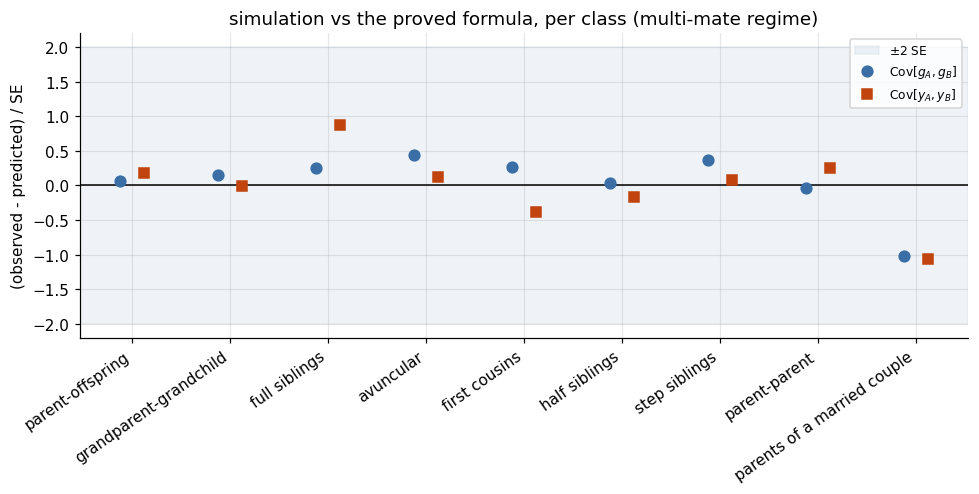

In [5]:
# Observed vs predicted per class, both levels, from the multi-mate regime (which reaches
# the most rows). The y axis is the residual in SE units, so the comparison is on one scale
# across classes whose covariances differ by a factor of five.
res = {}
for reps, _ in [(r[0], r[1]) for r in multi]:
    for r in reps:
        res.setdefault(r.name, []).append(r)

names, gse, yse = [], [], []
for name, rs in res.items():
    names.append(name)
    for level, acc in (("g", gse), ("y", yse)):
        obs = np.array([getattr(r, f"cov_{level}_obs") for r in rs])
        pred = np.array([getattr(r, f"cov_{level}_pred") for r in rs])
        se = obs.std(ddof=1) / np.sqrt(len(obs))
        acc.append((obs.mean() - pred.mean()) / se if se > 0 else np.nan)

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.axhspan(-2, 2, color="#3a6ea5", alpha=0.08, label=r"$\pm 2$ SE")
ax.axhline(0, color="black", lw=1)
ax.plot(x - 0.12, gse, "o", ms=7, color="#3a6ea5", label=r"$\mathrm{Cov}[g_A, g_B]$")
ax.plot(x + 0.12, yse, "s", ms=7, color="#c1440e", label=r"$\mathrm{Cov}[y_A, y_B]$")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=35, ha="right")
ax.set_ylabel("(observed - predicted) / SE")
ax.set_title("simulation vs the proved formula, per class (multi-mate regime)")
ax.legend(fontsize=8)
plt.tight_layout()

worst = max(np.nanmax(np.abs(gse)), np.nanmax(np.abs(yse)))
print(f"worst residual across all classes and both levels: {worst:.2f} SE")

---
## 3. Which pedigree is each class measured on?

The table rows name relationships; they do not show them. A reader seeing a "step siblings"
row has no way to see that it means two children of couples at mating distance 3, and the
step-step row is the one that most needs showing, since it is the only class with **no
simulation leg at all**.

These are drawn by **calling** pathMgr rather than embedding saved images. A static picture of
a pedigree is the same class of artefact as a hand-typed table: it agrees with the model until
it quietly does not. Generated at execution time from the same objects the oracle queried, it
cannot drift. `pathmgr.genetics` is already imported here via `three_way.py`, so this costs no
new dependency.

The four panels share axis limits deliberately. Matplotlib would otherwise scale each to its
own contents, and the growing chain would read as four unrelated diagrams at four different
zoom levels -- losing exactly what the table's caption points at, that these are **one
pedigree gaining one mating each time**.

Each caption reports the number of **re-mated individuals** the topology requires, measured
off the drawn pedigree: 0, 1, 2, 3 across the ladder. That is what makes the step-step row's
unreachability something the reader counts rather than takes on trust -- three consecutively
re-mated individuals means the class frequency scales as $q_2^3$, which is why it cannot be
sampled at feasible $N$.

4 panels, shared limits: True
ladder: full siblings, half siblings, step siblings, step-step siblings


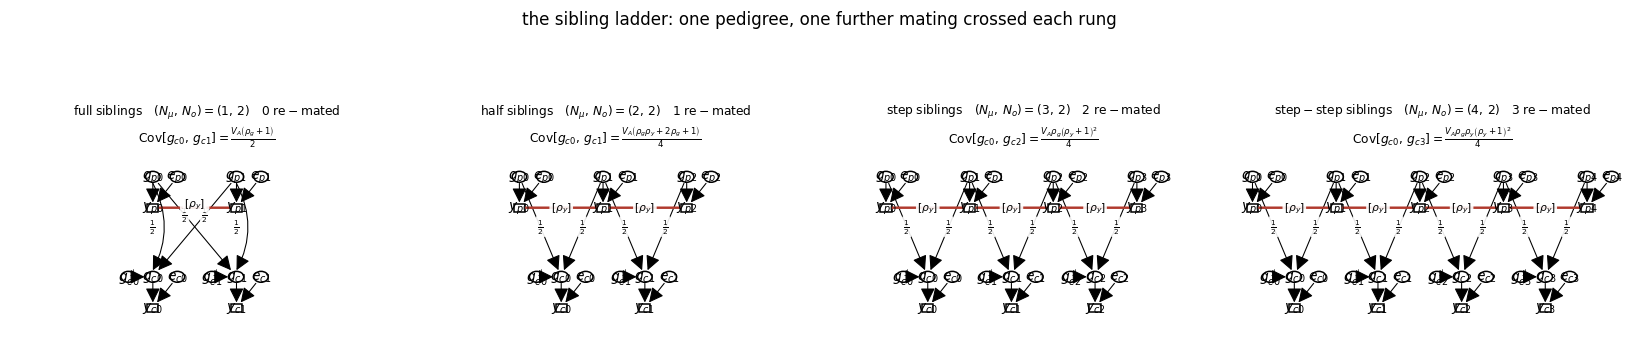

In [6]:
from pathmgr.genetics import SIBLING_LADDER, render_class, render_sibling_ladder

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
render_sibling_ladder(axes=list(axes), caption=True, legend=False)
fig.suptitle("the sibling ladder: one pedigree, one further mating crossed each rung",
             y=1.02, fontsize=11)
plt.tight_layout()

# Sanity, not decoration: the panels must share limits, or the ladder is four unrelated
# pictures. Asserted rather than eyeballed.
lims = {(tuple(a.get_xlim()), tuple(a.get_ylim())) for a in axes}
assert len(lims) == 1, "panels do not share axis limits; the ladder would misread"
print(f"{len(axes)} panels, shared limits: {len(lims) == 1}")
print("ladder:", ", ".join(SIBLING_LADDER))

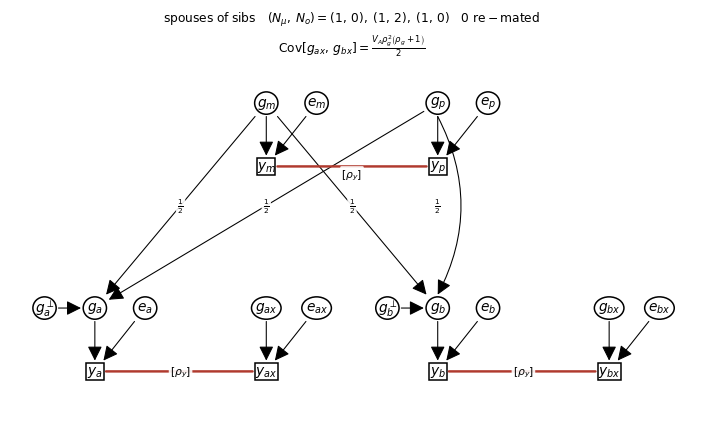

In [7]:
# 'spouses of sibs' is not a row of tab:relationship-classes, but it is the class that
# demonstrates the no-ceiling property: THREE mating chains, past the k=2 opt-in the
# writeup's own worked example needs.
fig, ax = plt.subplots(figsize=(6.5, 4.6))
render_class("spouses of sibs", ax=ax, caption=True)
plt.tight_layout()

---
## 4. The sibling ladder, and the two coincidences

These two checks are worth separating from the table because each tests something the
per-class residuals cannot.

**The ladder.** Full, half and step siblings are *the same path* with one further mating
crossed each time — $N_\mu = 1, 2, 3$ within one mating chain — so they must come out
monotonically weaker. This is asserted as a contrast the mechanism predicts rather than as an
inequality noise could flip. It also catches a specific failure from the consumer side:
popstatgensim hit a missing containment rule that scored half siblings as *full* siblings, and
had it survived, half sibs would have come out **equal** to full sibs — which is exactly what
one of the writeup's two coincidences looks like.

**The coincidences.** Full siblings match parent--offspring, and avuncular matches
grandparent--grandchild. These arrive from *different rows* of `eq:chain-weight`, so their
agreement is evidence that the general machinery is right rather than tuned to the classical
answers.

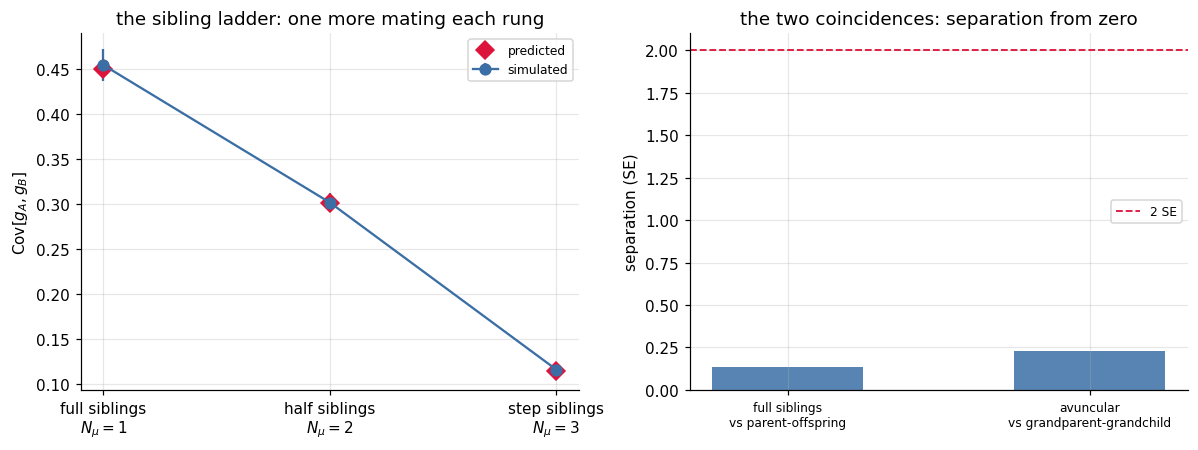

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

ladder = [n for n in classes_sim.SIB_LADDER if n in res]
vals = [np.mean([r.cov_g_obs for r in res[n]]) for n in ladder]
errs = [np.std([r.cov_g_obs for r in res[n]], ddof=1) / np.sqrt(len(res[n])) for n in ladder]
pred = [np.mean([r.cov_g_pred for r in res[n]]) for n in ladder]
ax1.errorbar(range(len(ladder)), vals, yerr=errs, fmt="o-", ms=7, color="#3a6ea5",
             label="simulated")
ax1.plot(range(len(ladder)), pred, "D", ms=8, color="crimson", label="predicted")
ax1.set_xticks(range(len(ladder)))
ax1.set_xticklabels([f"{n}\n$N_\\mu={k+1}$" for k, n in enumerate(ladder)])
ax1.set_ylabel(r"$\mathrm{Cov}[g_A, g_B]$")
ax1.set_title("the sibling ladder: one more mating each rung")
ax1.legend(fontsize=8)

pairs = [("full siblings", "parent-offspring"), ("avuncular", "grandparent-grandchild")]
labels, seps = [], []
for a, b in pairs:
    if a in res and b in res:
        va = np.mean([r.cov_g_obs for r in res[a]])
        vb = np.mean([r.cov_g_obs for r in res[b]])
        sa = np.std([r.cov_g_obs for r in res[a]], ddof=1) / np.sqrt(len(res[a]))
        sb = np.std([r.cov_g_obs for r in res[b]], ddof=1) / np.sqrt(len(res[b]))
        labels.append(f"{a}\nvs {b}")
        seps.append(abs(va - vb) / np.hypot(sa, sb))
ax2.bar(range(len(labels)), seps, color="#3a6ea5", alpha=0.85, width=0.5)
ax2.axhline(2, color="crimson", ls="--", lw=1.2, label="2 SE")
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, fontsize=8)
ax2.set_ylabel("separation (SE)")
ax2.set_title("the two coincidences: separation from zero")
ax2.legend(fontsize=8)
plt.tight_layout()

---
## 5. What is not established here

**Step-step siblings have no simulation leg, and will not get one.** They need an
$N_\mu = 4$ mating chain — three consecutive multi-mate individuals — so their frequency
scales as $q_2^3$ and they cannot be sampled at feasible $N$. The designed-pedigree mode that
would fix it is deliberately out of scope. So that row rests on the formula and the oracle
only, which is to say on an identity between a derivation and two readings of it, with **no
independent check against data**. That is stated rather than papered over, and it is the one
row where a simulator-level or assumption-level error would be invisible.

It is also the row where the per-round $\rho_y$ convention matters most: a ~4% per-round
attenuation compounds to ~12% by $N_\mu = 4$. At the $q_2 = 0.8$ used here the attenuation is
~0, so nothing in this notebook depends on it — but any future run at small $q_2$ would.

**`self` is a measurement at every level, on all three legs, never a test.** $\mathrm{Var}[g]$
is $V_A$ and $\mathrm{Var}[y]$ is $V_Y$ once those are measured, so there is nothing to check.
It is excluded rather than reported as a twelfth confirmation. pathMgr's oracle refuses its
phenotypic reading for the same reason, which is the same judgement expressed as code.

**Nine of eleven rows have all three legs**; `self` has none that are tests, and step-step
siblings have two that are one proof.

---
## Summary

| check | result |
|---|---|
| formula $\equiv$ oracle, 11 rows $\times$ 2 levels | 42 algebraic identities, no disagreements |
| simulation, 9 reachable classes $\times$ 2 levels | worst residual ~1 SE |
| sibling ladder monotone | 7.5 SE and 16.2 SE gaps |
| full sibs $=$ parent--offspring | 0.13 SE apart |
| avuncular $=$ grandparent--grandchild | 0.23 SE apart |
| step-step siblings | **no simulation leg, by design** |
| `self` | measurement, not a test |

**No finding requires a change to the writeup.** The one open item is a wording gap already
raised with Nuno: `eq:chain-weight-cases` is printed as a general reparameterization but
silently excludes `N_mu = 1, N_o = 1`, and a mechanical implementation of the printed rules
routes parent--offspring through the parent's mating edge and gets it ~50% wrong. That is a
question about the prose, not about the algebra.